# Marketing Campaign Analysis

## LIBRARIES USED

In [37]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

## DATA LOADING

### Information about the dataset

**marketing_data.csv**: Main dataset with customer-level information such as their basic info, purchase channels, responses and complains to campaigns etc.


**marketing_data_dictionary.csv**: Field names and descriptions.

In [38]:
df_raw = pd.read_csv("/home/nithan-b-s/Documents/Marketing_Campaign_Analytics/Data/marketing_campaign_data.csv")
dd     = pd.read_csv("/home/nithan-b-s/Documents/Marketing_Campaign_Analytics/Data/marketing_data_dictionary.csv")

## EXPLORATORY DATA ANALYSIS (EDA)

### Univariate Analysis

In [39]:
dd

,Field,Description
0,ID,Customer's unique identifier
1,Year_Birth,Customer's birth year
2,Education,Customer's education level
3,Marital_Status,Customer's marital status
4,Income,Customer's yearly household income
5,Kidhome,Number of children in customer's household
6,Teenhome,Number of teenagers in customer's household
7,Dt_Customer,Date of customer's enrollment with the company
8,Recency,Number of days since customer's last purchase
9,MntWines,Amount spent on wine in the last 2 years


In [40]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  str    
 3   Marital_Status       56000 non-null  str    
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  str    
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null  int64  
 1

In [41]:
print(f"Raw dataset shape : {df_raw.shape} (customers, features)")
print(f"Columns           : {list(df_raw.columns)}")
df_duplicate = df_raw.duplicated(subset=['ID']).sum()
print(f"Duplicates = {df_duplicate}")
missing = df_raw.isnull().sum()
# print(missing)
print(f"Missing values    : {missing[missing > 0]}")


Raw dataset shape : (56000, 28) (customers, features)
Columns           : ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country']
Duplicates = 0
Missing values    : Series([], dtype: int64)


our data looks pretty clean with **no duplicated** or **null values**

In [42]:
df_raw.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada


In [19]:
# Descriptive statistics
df_raw.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,5.600000e+04,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,...,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,8.389352e+06,1971.666696,57252.189521,0.539911,0.362143,63.221107,246.981482,16.152661,268.294018,51.097732,...,2.110750,4.706411,5.170107,0.062393,0.056821,0.045661,0.134446,0.014411,0.147589,0.007625
std,4.844638e+06,12.211066,34307.247999,0.521349,0.510567,31.157066,358.569481,33.931463,342.165712,73.226860,...,2.357824,2.896366,2.555911,0.241870,0.231503,0.208750,0.341134,0.119178,0.354696,0.086988
min,3.600000e+01,1936.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.187372e+06,1963.000000,28252.025000,0.000000,0.000000,35.000000,0.000000,0.000000,42.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.383784e+06,1973.000000,58838.550000,1.000000,0.000000,71.000000,64.000000,0.000000,107.000000,13.000000,...,1.000000,4.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.258576e+07,1981.000000,86930.650000,1.000000,1.000000,93.000000,353.000000,15.000000,363.000000,71.000000,...,3.000000,6.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.677716e+07,1996.000000,258027.500000,2.000000,2.000000,99.000000,1493.000000,199.000000,1341.000000,259.000000,...,14.000000,13.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
df = df_raw.copy()

### Convert date type

In [89]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

### Numeric data analysis

In [ ]:
num_vars = [
    'Year_Birth', 'Income', 'Kidhome','Teenhome','Recency', 
    'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'
    ] 

fig, axes = plt.subplots(nrows=4,ncols=4) # create figure and axes

axes = axes.flatten() # Flatten the axes array for easy iteration

for i,col in enumerate(num_vars):
    ax = axes[i]
    box = ax.boxplot(df[col], patch_artist=True)
    ax.set_xticklabels([])
    ax.set_title(col)
    ax.yaxis.grid(True)

fig.set_size_inches(18.5,14)
plt.figure(figsize=(10,6))
plt.tight_layout()
plt.show()

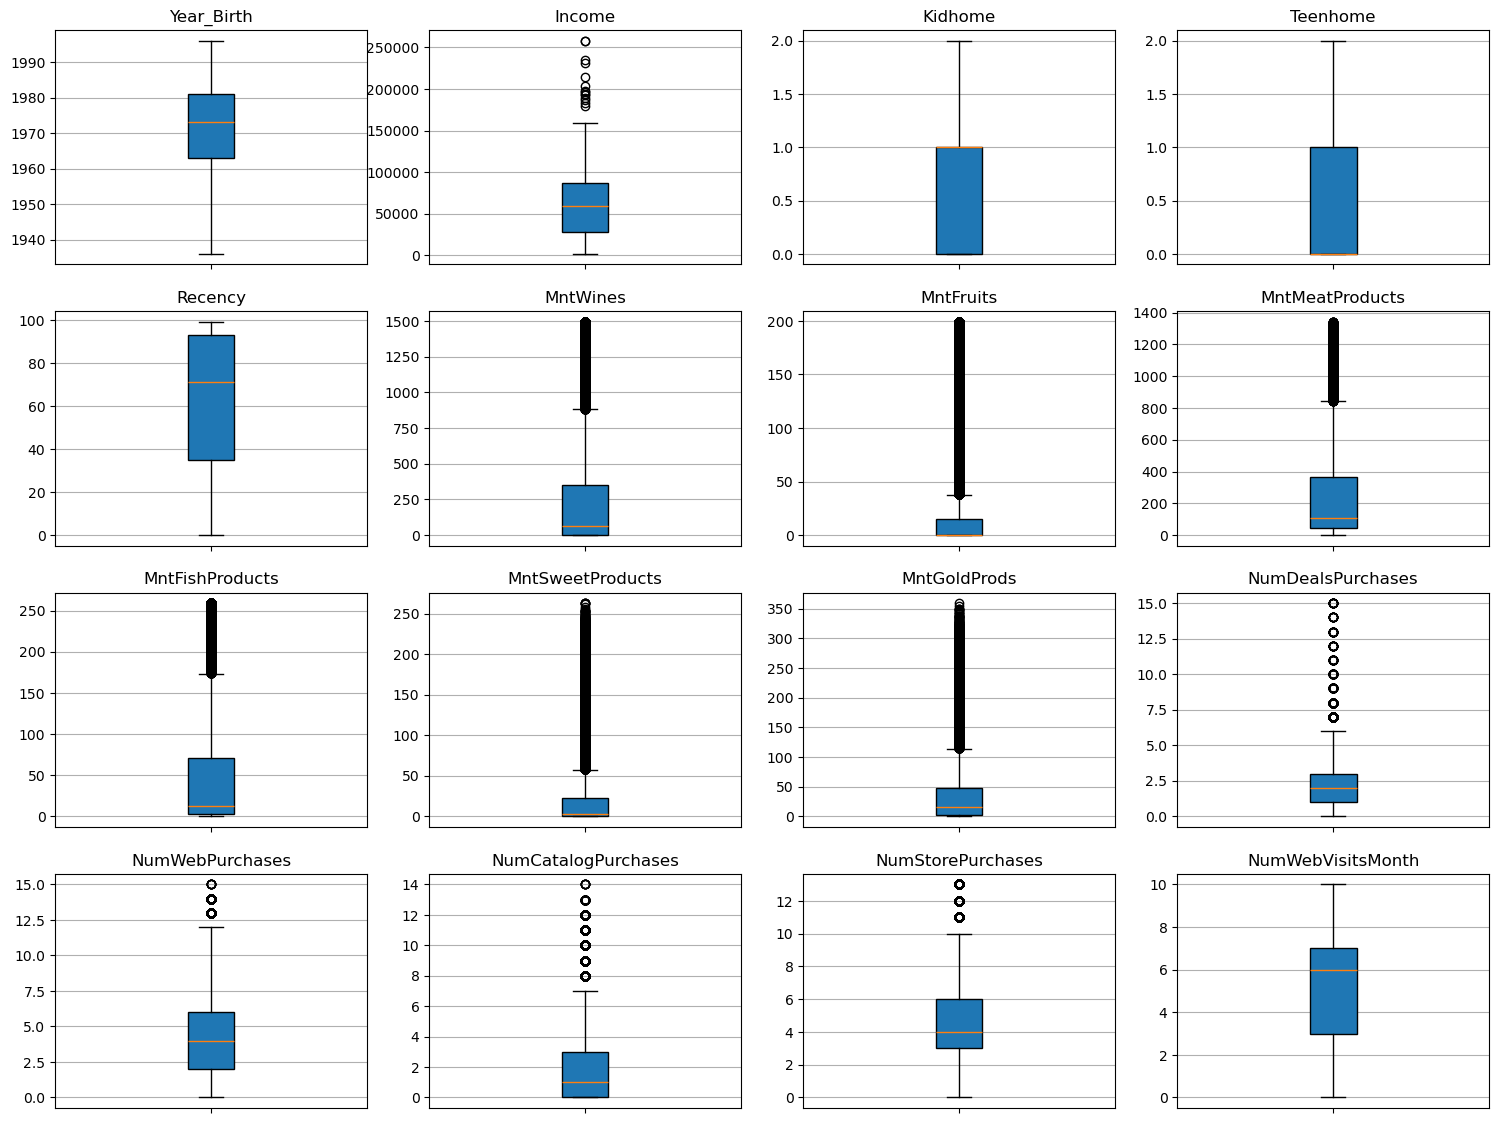

- `Year_Birth`: slightly longer bottom whisker, suggesting a "tail" of **older customers**.

- `Income`: There are few points above **150k**, with one reaching above **250k**.But majority values are between **25-90k**.

- `KidHome` and `Teenhome`: both contains discrete values, spread between the values **0,1 and 2**. seems appropriate.

- `Recency`: Uniformly distributed, ranging between **0 and 100**, with no outliers.

- `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` all behave similarly, **skewed to the right**, although in different scales.

- `NumDealPurchases`, `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases` also show similar behaviors, skewed to the right.

- `NumWebVisitsMonth` except from median being at 6, it seems to be uniformly distributed.

### Remove outliers (±3σ)

outliers can significantly impact the results

In [46]:
income_mean  = df["Income"].mean()
income_std   = df["Income"].std()
income_upper = income_mean + 3 * income_std
income_lower = max(0, income_mean - 3 * income_std)
n_outliers   = ((df["Income"] < income_lower) | (df["Income"] > income_upper)).sum()
print(f"Income outliers removed : {n_outliers}")
df = df[(df["Income"] >= income_lower) & (df["Income"] <= income_upper)]

Income outliers removed : 14


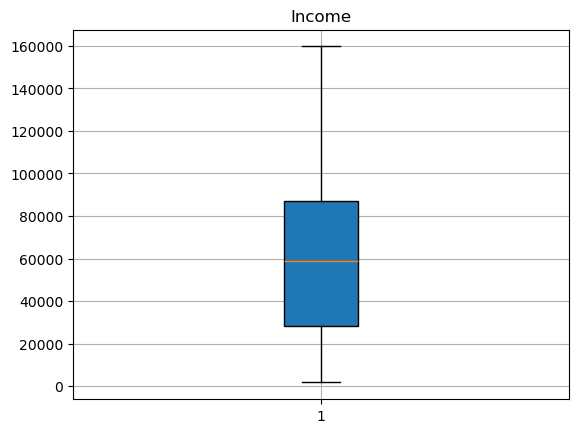

In [47]:
plt.boxplot(df["Income"], patch_artist=True)
plt.title('Income')
plt.grid()
plt.show()

### Categorical data analysis

In [48]:
df['Marital_Status'].unique()

<StringArray>
['Together', 'Single', 'Married', 'Divorced', 'YOLO', 'Alone', 'Widow',
 'Absurd']
Length: 8, dtype: str

In [49]:
counts = df['Marital_Status'].value_counts().sort_index()
percentages = df['Marital_Status'].value_counts(normalize=True).sort_index() * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages
})

print(result)

                Count  Percentage (%)
Marital_Status                       
Absurd            733        1.309256
Alone             910        1.625406
Divorced         6459       11.536813
Married         13682       24.438252
Single          12235       21.853678
Together        17698       31.611474
Widow            3539        6.321223
YOLO              730        1.303897


From this we can see there are some words like **'YOLO', 'Alone', 'Absurd'** which do not give the right meaning of their `Marital_Status`, we will change all these words to **Single** because the are similar meaning to this 

In [50]:
df.loc[df['Marital_Status'].isin(['Single', 'YOLO', 'Alone', 'Absurd']), ['Marital_Status', 'Kidhome','Teenhome']]

,Marital_Status,Kidhome,Teenhome
1,Single,1,1
8,Single,1,0
10,Single,1,0
13,Single,1,0
14,YOLO,1,1
...,...,...,...
55985,Single,1,1
55986,Single,1,0
55990,Alone,1,0
55991,Single,0,0


In [51]:
marital_map = {"Absurd": "Single", "YOLO": "Single", "Alone": "Single"}
df["Marital_Status"] = df["Marital_Status"].replace(marital_map)

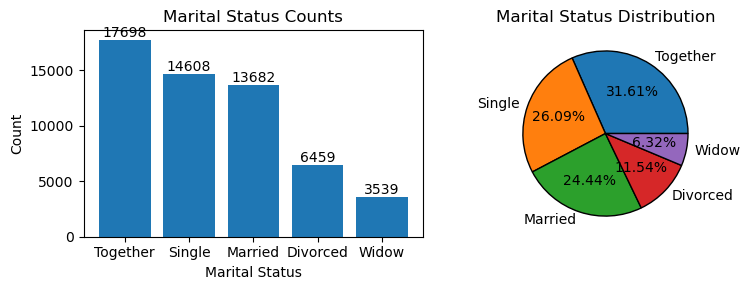

In [52]:
# Get the value counts for 'Marital_Status'
marital_counts = df['Marital_Status'].value_counts()

# Create a figure with two subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

# Plot the bar plot on the first subplot
bars = axes[0].bar(marital_counts.index, marital_counts.values)
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Count')
axes[0].set_title('Marital Status Counts')

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')

# Plot the pie plot on the second subplot
axes[1].pie(marital_counts, labels=marital_counts.index, autopct='%.2f%%', wedgeprops={'edgecolor':"Black"})
axes[1].set_title('Marital Status Distribution')

# Adjust spacing between subplots
fig.tight_layout()

# Display the plot
plt.show()


In [53]:
df['Education'].unique() # to check unique values

<StringArray>
['Graduation', 'Master', '2n Cycle', 'Basic', 'PhD']
Length: 5, dtype: str

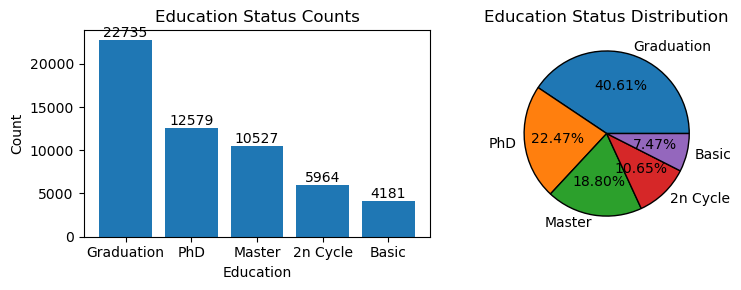

In [54]:
edu_counts = df['Education'].value_counts()

# Create a figure with two subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

# Plot the bar plot on the first subplot
bars = axes[0].bar(edu_counts.index, edu_counts.values)
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Count')
axes[0].set_title('Education Status Counts')

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height, height, ha='center', va='bottom')

# Plot the pie plot on the second subplot
axes[1].pie(edu_counts, labels=edu_counts.index, autopct='%.2f%%',
           wedgeprops={'edgecolor':"Black"})
axes[1].set_title('Education Status Distribution')

# Adjust spacing between subplots
fig.tight_layout()

# Display the plot
plt.show()

- `Education`: The sample shows people have completed graduation followed by PhD and Masters.

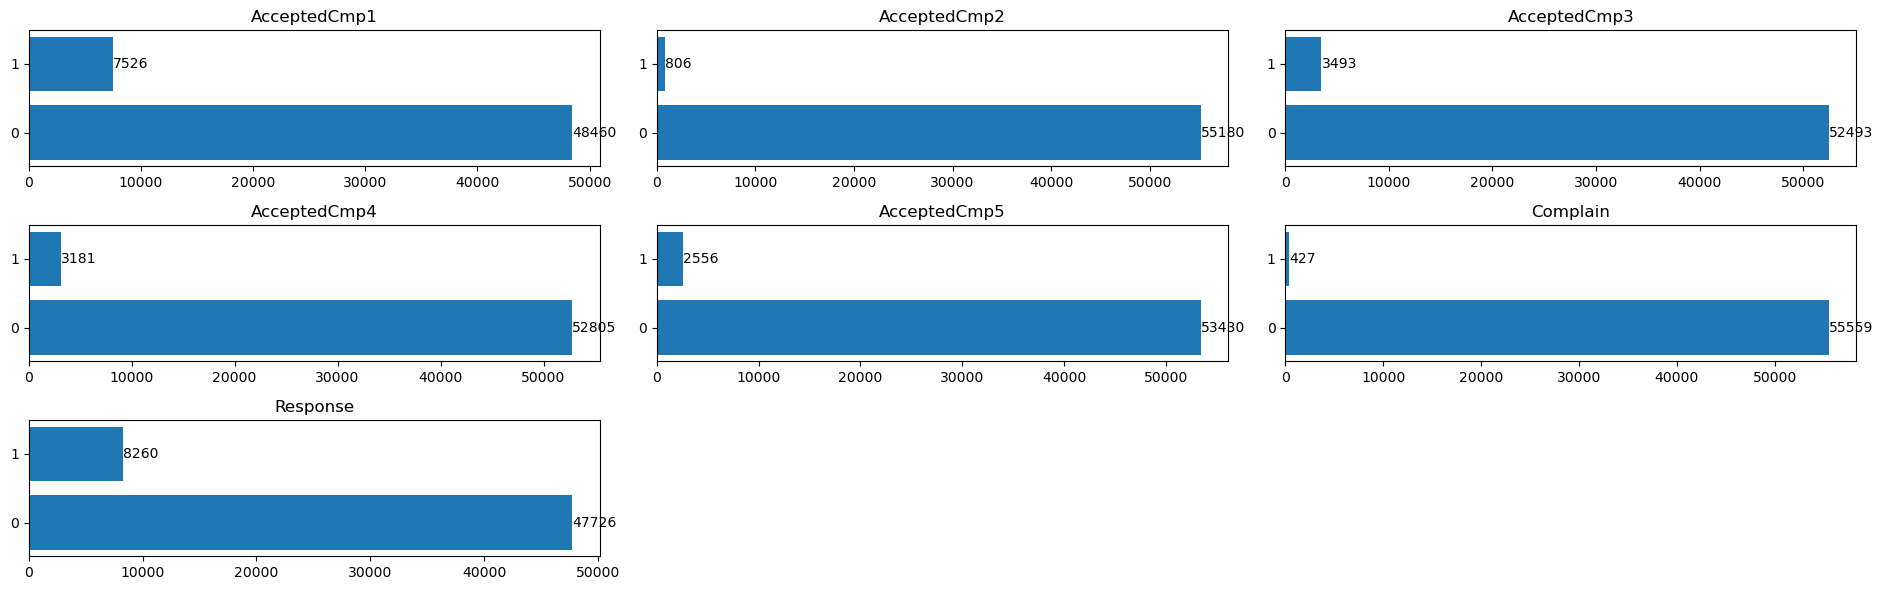

In [55]:
# AcceptedCmp, Complain and Response
cat_vars = [
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
    'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response'
]

# create figure and axes
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(19, 6)) 

for i, ax in enumerate(axes.flatten()):
    if i < len(cat_vars):
        counts = df[cat_vars[i]].value_counts()
        ax.barh(counts.index, counts.values)  # Interchanged x and y(barh)
        ax.set_title(cat_vars[i])

        # Set y-tick labels
        ax.set_yticks(range(len(counts)))  # Changed to set_yticks
        ax.set_yticklabels(counts.index)  # Changed to set_yticklabels

        # Add values inside the bars 
        for j, v in enumerate(counts.values):
            ax.text(v, j, str(v), ha='left', va='center', weight='medium', size='medium')  

    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

- `AcceptedCmp1`, `AcceptedCmp2`, `AcceptedCmp3`, `AcceptedCmp4` and `AcceptedCmp5`: values are unbalanced, with many more 0s than 1s. 

- `AcceptedCmp2` is more unbalanced than the others.

- `Complain`: highly unbalanced.

- `Response`: not highly unbalanced.

In [57]:
# more detail on complain 
df.Complain.describe()

count    55986.000000
mean         0.007627
std          0.086999
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Complain, dtype: float64

- As we can see only 0.7% of customers seem to have complained.

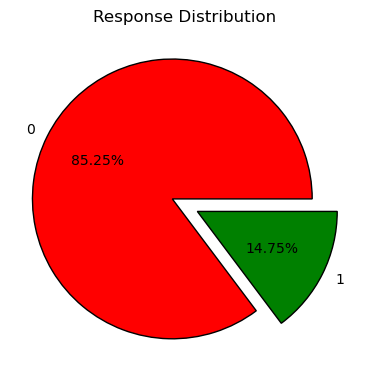

In [58]:
# Get the value counts for 'Response'
response_counts = df['Response'].value_counts()

# Create a figure with one subplot
fig, ax = plt.subplots(figsize=(4, 4))

# Create the pie plot for 'Response' in the subplot
ax.pie(response_counts, labels=response_counts.index, autopct='%.2f%%', colors=['red', 'green'],
       explode=[0.1, 0.1], wedgeprops={'edgecolor': "Black"})
ax.set_title('Response Distribution')

# Adjust spacing between subplots
fig.tight_layout()

# Display the plot
plt.show()

### Date

In [59]:
earliest_date = df["Dt_Customer"].min()
latest_date = df["Dt_Customer"].max()

print("Earliest:", earliest_date)
print("Latest:", latest_date)

Earliest: 2012-07-30 00:00:00
Latest: 2014-06-29 00:00:00


- We see that dates frange from **30/07/2012** to **29/06/2014**.

<Axes: xlabel='Dt_Customer'>

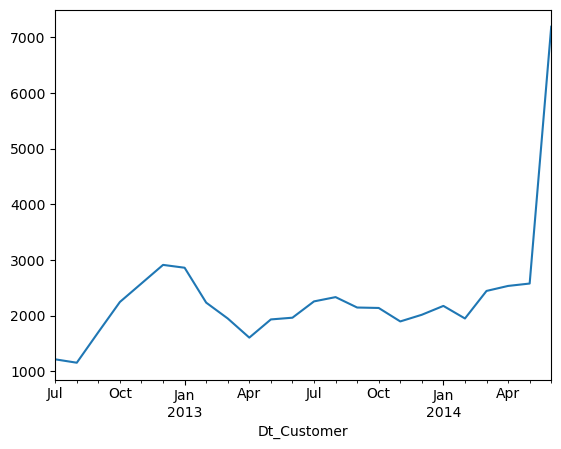

In [61]:
df.groupby(
    pd.Grouper(key='Dt_Customer', freq='ME')
    ).count().ID.plot(x='index')

- While registration was stable from 2012 to early 2014, a significant 3x spike occurred in June 2014. This warrants further investigation into whether this was a successful marketing 'blitz' or a data entry anomaly where historical records were backfilled into the final month of the dataset.

Spike Group Median Recency: 69.0
Normal Group Median Recency: 71.0


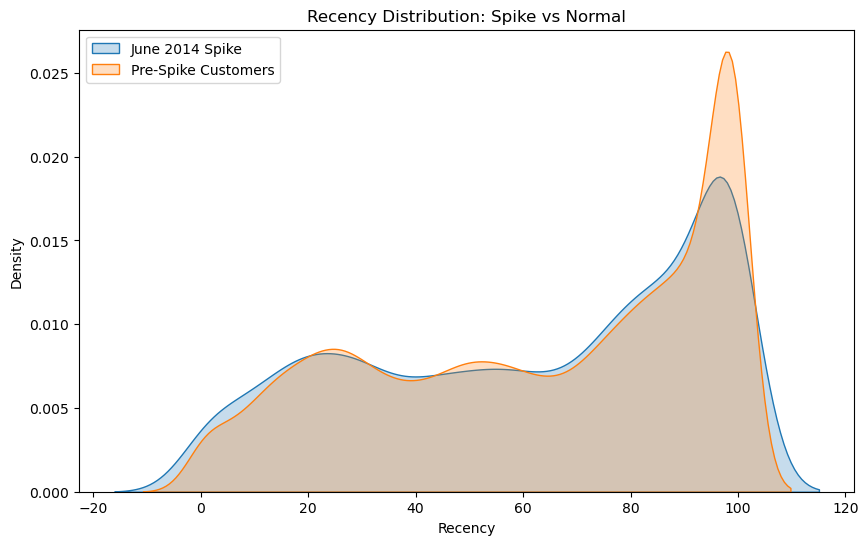

In [62]:
# 1. Identify the spike period (adjust the date based on your exact data)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
spike_group = df[df['Dt_Customer'] >= '2014-06-01']
normal_group = df[df['Dt_Customer'] < '2014-06-01']

# 2. Compare Recency stats
print("Spike Group Median Recency:", spike_group['Recency'].median())
print("Normal Group Median Recency:", normal_group['Recency'].median())

# 3. Visual Comparison
plt.figure(figsize=(10, 6))
sns.kdeplot(spike_group['Recency'], label='June 2014 Spike', fill=True)
sns.kdeplot(normal_group['Recency'], label='Pre-Spike Customers', fill=True)
plt.title('Recency Distribution: Spike vs Normal')
plt.legend()
plt.show()

- spike is not a sudden influx of brand-new customers from a marketing campaign.
- If those 7,000+ people actually joined in June 2014, their Recency should be very low (close to 0).
- Instead, the "Spike Group" has the same "old" customers (Recency ~70-100) as the rest of the database.
- This concludes issue in data of `DT_Customer` while they preserved their `Recency`

## FEATURE ENGINEERING

In [64]:
REFERENCE_DATE = pd.Timestamp("2015-01-01")
df["Customer_Tenure_Days"]   = (REFERENCE_DATE - df["Dt_Customer"]).dt.days
df["Customer_Tenure_Months"] = df["Customer_Tenure_Days"] // 30
# Format as string so MySQL receives a proper DATE value
df["Dt_Customer"] = df["Dt_Customer"].dt.strftime("%Y-%m-%d")

### Derive Age

In [65]:
df["Age"] = REFERENCE_DATE.year - df["Year_Birth"]

### Total Spending

In [66]:
df["Total_Spend"] = (
    df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]
    + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
)

### Total Purchase

In [67]:

df["Total_Purchases"] = (
    df["NumWebPurchases"] + df["NumCatalogPurchases"]
    + df["NumStorePurchases"] + df["NumDealsPurchases"]
)

### Number of children

In [ ]:
df["Children"] = df["Kidhome"] + df["Teenhome"]

### Total accepted campaings

In [ ]:
df["Total_Campaign_Accepted"] = (
    df["AcceptedCmp1"] + df["AcceptedCmp2"] + df["AcceptedCmp3"]
    + df["AcceptedCmp4"] + df["AcceptedCmp5"] + df["Response"]
)

### Accepted campaign

In [69]:
df["Any_Campaign_Accepted"] = (df["Total_Campaign_Accepted"] > 0).astype(int)

### Age bands — stored as plain VARCHAR in MySQL

In [70]:

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[17, 29, 39, 49, 59, 69, 90],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
).astype(str)
df["Age_Band"] = df["Age_Band"].replace("nan", None)


In [ ]:
# Count of each Age_Band
age_counts = df['Age_Band'].value_counts().sort_index()  # keep sorted by band
age_labels = age_counts.index

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,6))

# ---- Left: Vertical Bar Chart ----
sns.barplot(x=age_labels, y=age_counts.values, ax=axes[0])
axes[0].set_title("Customer Count by Age Band")
axes[0].set_xlabel("Age Band")
axes[0].set_ylabel("Count")

# Add value labels on top of bars
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 5, f"{v:,}", ha='center')

# ---- Right: Pie Chart ----
axes[1].pie(age_counts.values, labels=age_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Customer Percentage by Age Band")

# Adjust layout
plt.tight_layout()
plt.show()

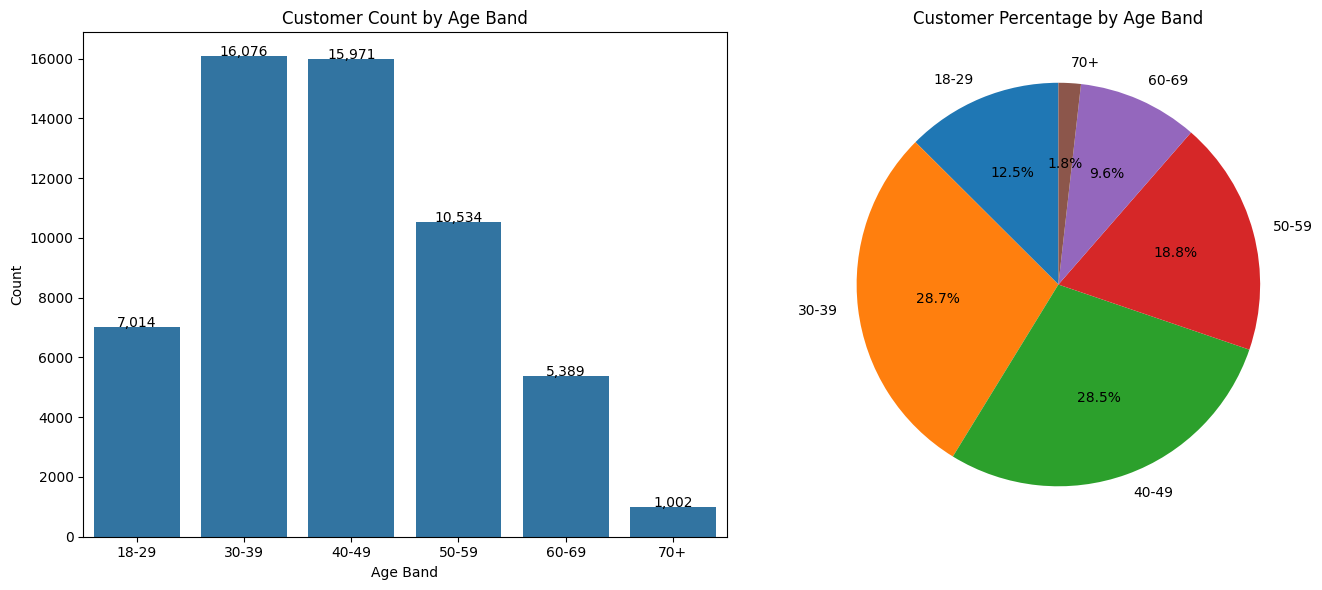

### Income bands

In [72]:
df["Income_Band"] = pd.cut(
    df["Income"],
    bins=[0, 25000, 50000, 75000, 100000, 300000],
    labels=["<25K", "25K-50K", "50K-75K", "75K-100K", ">100K"]
).astype(str)
df["Income_Band"] = df["Income_Band"].replace("nan", None)

spend_90th = df["Total_Spend"].quantile(0.90)
spend_75th = df["Total_Spend"].quantile(0.75)
spend_50th = df["Total_Spend"].quantile(0.50)
print(f"Total Spend — 50th: {spend_50th:.0f}, 75th: {spend_75th:.0f}, 90th: {spend_90th:.0f}")

Total Spend — 50th: 441, 75th: 1020, 90th: 1564


## RULE-BASED SEGMENTATION

In [73]:
df["Seg_High_Income"]         = (df["Income"] > 75000).astype(int)
df["Seg_Young_Customer"]      = (df["Age"] < 30).astype(int)
df["Seg_Campaign_Responder"]  = (df["Response"] == 1).astype(int)
df["Seg_High_Web_Engagement"] = (df["NumWebVisitsMonth"] > 5).astype(int)
df["Seg_Family_Customer"]     = (df["Children"] > 0).astype(int)
df["Seg_High_Spender"]        = (df["Total_Spend"] > spend_90th).astype(int)

In [74]:
def assign_primary_segment(row):
    if row["Seg_High_Spender"] == 1 and row["Seg_High_Income"] == 1:
        return "Premium"
    elif row["Seg_High_Spender"] == 1:
        return "High Spender"
    elif row["Seg_High_Income"] == 1:
        return "High Income"
    elif row["Seg_Campaign_Responder"] == 1:
        return "Campaign Responder"
    elif row["Seg_High_Web_Engagement"] == 1:
        return "Web Engaged"
    elif row["Seg_Family_Customer"] == 1:
        return "Family"
    elif row["Seg_Young_Customer"] == 1:
        return "Young"
    else:
        return "Standard"

In [75]:
df["Primary_Segment"] = df.apply(assign_primary_segment, axis=1)

print("\nSegment distribution:")
print(df["Primary_Segment"].value_counts())
print("\nSegment flag counts:")
for seg in ["Seg_High_Income", "Seg_Young_Customer", "Seg_Campaign_Responder",
            "Seg_High_Web_Engagement", "Seg_Family_Customer", "Seg_High_Spender"]:
    print(f"  {seg}: {df[seg].sum():,} ({df[seg].mean()*100:.1f}%)")


Segment distribution:
Primary_Segment
Web Engaged           19722
High Income           15633
Family                 8864
Premium                4135
Campaign Responder     3302
Standard               2547
High Spender           1461
Young                   322
Name: count, dtype: int64

Segment flag counts:
  Seg_High_Income: 19,768 (35.3%)
  Seg_Young_Customer: 7,014 (12.5%)
  Seg_Campaign_Responder: 8,260 (14.8%)
  Seg_High_Web_Engagement: 29,967 (53.5%)
  Seg_Family_Customer: 38,216 (68.3%)
  Seg_High_Spender: 5,596 (10.0%)


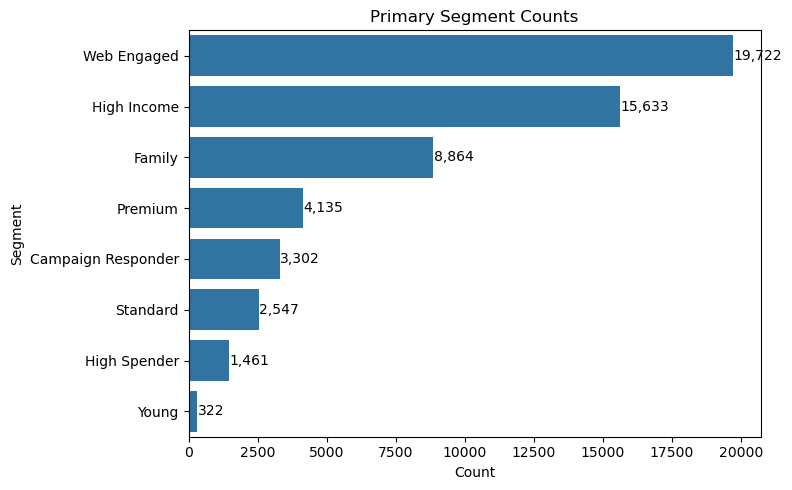

In [76]:
# Get segment counts
segment_counts = df['Primary_Segment'].value_counts()
segment_labels = segment_counts.index

# Create subplots
fig, axes = plt.subplots(1, 1, figsize=(8, 5))  # only one plot here

# ---- Bar chart (counts) ----
sns.barplot(
    x=segment_counts.values,
    y=segment_labels,
    ax=axes
)

axes.set_title("Primary Segment Counts")
axes.set_xlabel("Count")
axes.set_ylabel("Segment")

# Add count labels on bars
for i, count in enumerate(segment_counts.values):
    axes.text(count + 5, i, f"{count:,}", va='center')

plt.tight_layout()
plt.show()

## Bivariate

In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 55986 entries, 0 to 55999
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       55986 non-null  int64  
 1   Year_Birth               55986 non-null  int64  
 2   Education                55986 non-null  str    
 3   Marital_Status           55986 non-null  str    
 4   Income                   55986 non-null  float64
 5   Kidhome                  55986 non-null  int64  
 6   Teenhome                 55986 non-null  int64  
 7   Dt_Customer              55986 non-null  str    
 8   Recency                  55986 non-null  int64  
 9   MntWines                 55986 non-null  int64  
 10  MntFruits                55986 non-null  int64  
 11  MntMeatProducts          55986 non-null  int64  
 12  MntFishProducts          55986 non-null  int64  
 13  MntSweetProducts         55986 non-null  int64  
 14  MntGoldProds             55986 non-nul

In [79]:
num_vars

['Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth']

In [80]:
num_vars_bi = ['Age', 'Income','Total_Spend','Total_Purchases','Children','Total_Campaign_Accepted','Any_Campaign_Accepted','Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds']

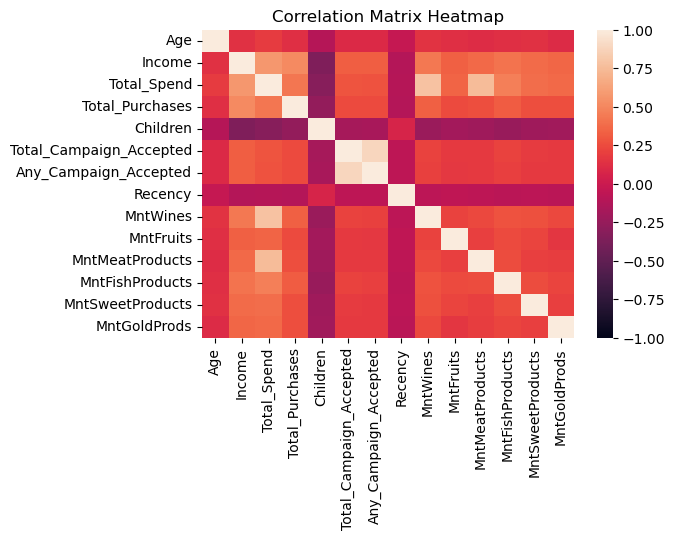

In [81]:
corr_matrix = df[num_vars_bi].corr()

# Set up the matplotlib figure
plt.figure(figsize=(6, 4))

# Create a heatmap with the mask applied
sns.heatmap(corr_matrix, annot=False, vmin=-1,vmax=1)

plt.title('Correlation Matrix Heatmap')
plt.show()


| Relationship                     | Correlation Strength | Business Interpretation                                                                 |
|----------------------------------|---------------------|------------------------------------------------------------------------------------------|
| Income vs. Total_Spend           | Very High (+)       | Income is the primary driver of wallet share.                                           |
| Children vs. Total_Spend         | High (-)            | Households with children are "low-value" segments for luxury goods.                     |
| Campaigns vs. Total_Spend        | Moderate (+)        | Marketing campaigns are successfully targeting the right (high-spend) people.           |
| Age vs. MntWines                | Mild (+)            | The "Wine" segment skews older and wealthier.                                           |

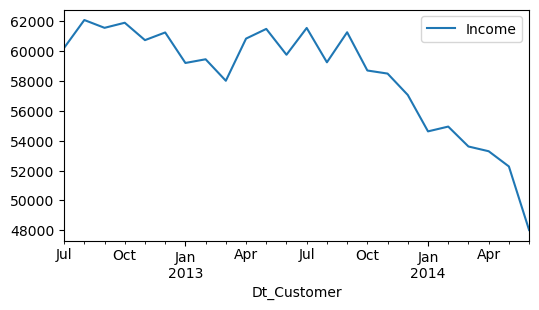

In [93]:
data_home = df[['Income', 'Dt_Customer']]
grouped_data = data_home.groupby(pd.Grouper(key='Dt_Customer', freq='ME')).mean()

grouped_data.plot(figsize=(6,3))
plt.show()

- Average income seems to be getting lower with time.

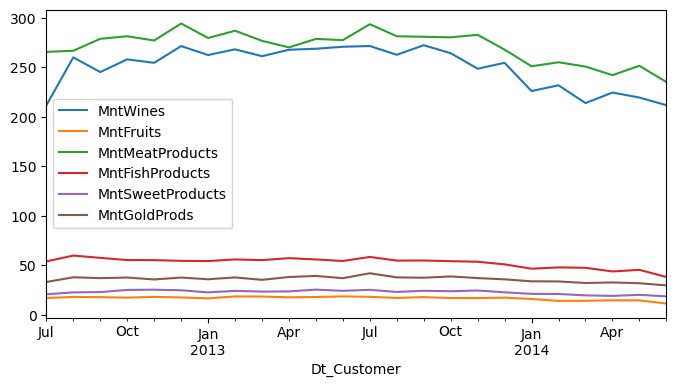

In [95]:
mnt = df.loc[:,df.columns.str.contains('Mnt')].columns
data_spent = df[['Dt_Customer']+list(mnt)]
grouped_data= data_spent.groupby(pd.Grouper(key='Dt_Customer', freq='ME')).mean()

grouped_data.plot(figsize=(8,4))
plt.show()

- Overall sales of most products seem to be decreasing over time.

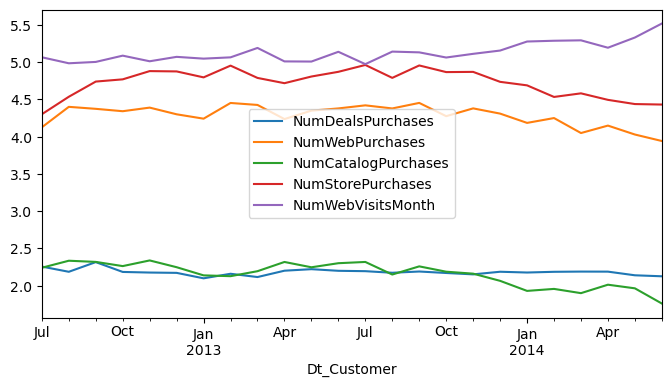

In [97]:
# Type of Purchase over Time
purchased = df.loc[:,df.columns.str.contains('Num')].columns
data_purchase_type = df[['Dt_Customer']+list(purchased)]
grouped_data= data_purchase_type.groupby(pd.Grouper(key='Dt_Customer', freq='ME')).mean()

grouped_data.plot(figsize=(8,4))
plt.show()

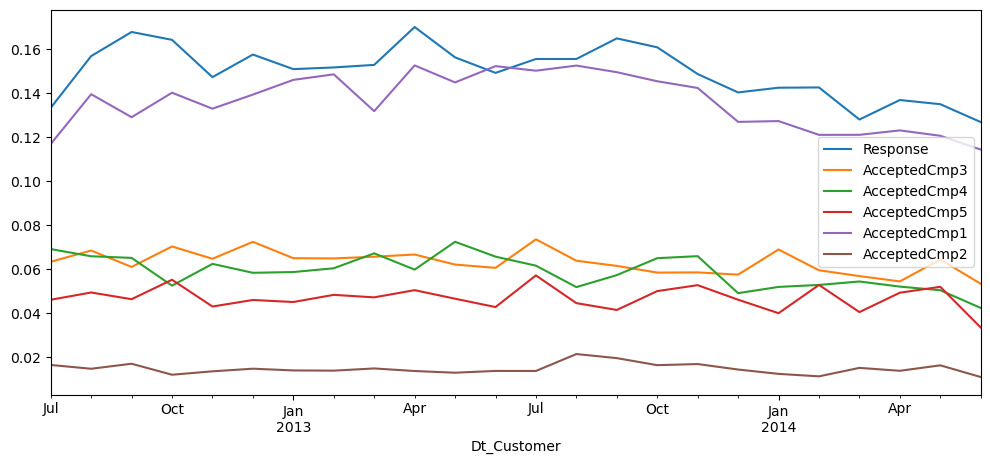

In [101]:
# Complain, Response, and Acceptance over Time
cmp = df.loc[:,df.columns.str.contains('Cmp')].columns
data_cmp = df[['Dt_Customer','Response']+list(cmp)]
grouped_data= data_cmp.groupby(pd.Grouper(key='Dt_Customer', freq='ME')).mean()

grouped_data.plot(figsize=(12,5))
plt.show()

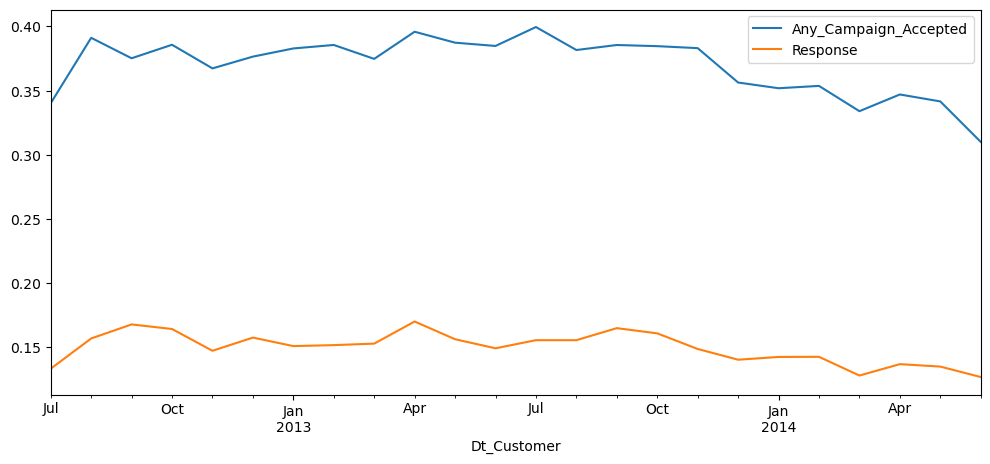

In [102]:
data_cmp_com = df[['Dt_Customer','Any_Campaign_Accepted','Response']]
grouped_data_cmb = data_cmp_com.groupby(pd.Grouper(key='Dt_Customer', freq='ME')).mean()

grouped_data_cmb.plot(figsize=(12,5))
plt.show()

**Campaign Conversion Trends**

- High Baseline Loyalty: Customers registered between July 2012 and mid-2013 show the highest responsiveness to marketing efforts, specifically for the latest Response campaign and Campaign 1.

- Recent Acquisition Quality: There is a visible decay in conversion rates for customers acquired in 2014. This suggests that while registration numbers spiked during this period (as seen in previous plots), the "quality" or "intent" of these new users is lower.

- Campaign Heirarchy: Based on historical data, Campaign 1 was the most successful, followed by Campaigns 3 and 4. Campaign 2 consistently underperformed, suggesting its offer or targeting strategy should be avoided in the future.

In [103]:
# Marital Status vs Education
pd.crosstab(
    index=df['Marital_Status'],columns=df['Education'],
    normalize='columns'
    ).round(2)

Education,2n Cycle,Basic,Graduation,Master,PhD
Marital_Status,,,,,
Divorced,0.06,0.02,0.10,0.10,0.22
Married,0.37,0.36,0.24,0.25,0.16
Single,0.23,0.24,0.26,0.27,0.28
Together,0.31,0.36,0.30,0.35,0.31
Widow,0.03,0.02,0.11,0.03,0.04


In our Sample
- 37% of people who have a **2n Cycle** education are married.

- From our data it is understood that people who have filled their `Marital_Status` as **Togather** are very high (all are above 30%) followed by **Single** (steady 25%) and **Married** (higher the education lower is their rate)

In [104]:
# Education vs Response
pd.crosstab(
    index=df['Education'],columns=df['Response'],
    normalize='columns'
    ).round(2)

Response,0,1
Education,,
2n Cycle,0.11,0.08
Basic,0.08,0.05
Graduation,0.39,0.48
Master,0.19,0.18
PhD,0.23,0.21


- People with Higher Education are more likely to accept offers.

### Campaign Response Rates

In [111]:
print("\n--- Campaign Response Rates ---")
for col in ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
            "AcceptedCmp4", "AcceptedCmp5", "Response"]:
    print(f"  {col}: {df[col].mean()*100:.2f}%")



--- Campaign Response Rates ---
  AcceptedCmp1: 13.44%
  AcceptedCmp2: 1.44%
  AcceptedCmp3: 6.24%
  AcceptedCmp4: 5.68%
  AcceptedCmp5: 4.57%
  Response: 14.75%


### Avg Total Spend by Education


In [ ]:
# Compute mean spend per education
edu_mean = df.groupby("Education")["Total_Spend"].mean().sort_values(ascending=False)

# Bar plot
plt.figure(figsize=(8,5))
sns.barplot(x=edu_mean.values, y=edu_mean.index)
plt.title("Average Total Spend by Education Level")
plt.xlabel("Average Total Spend")
plt.ylabel("Education Level")
    
plt.show()

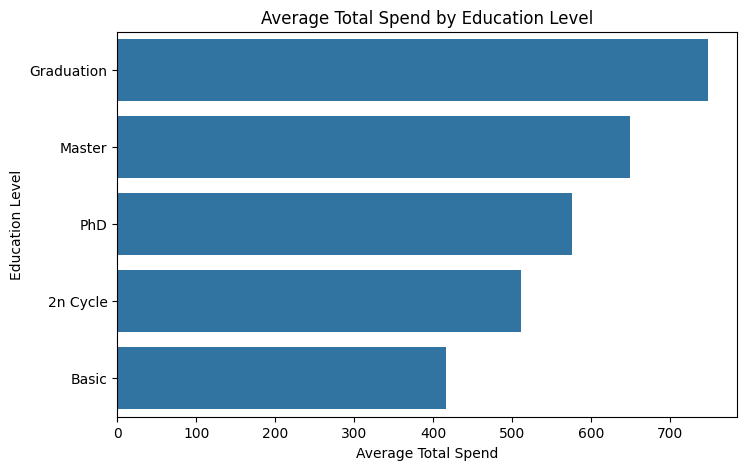

### Avg Total Spend by Marital Status

In [ ]:
print("\n--- Avg Total Spend by Marital Status ---")
avg_martial_status = df.groupby("Marital_Status")["Total_Spend"].mean().sort_values(ascending=False).round(1)

plt.figure(figsize = (8,5))
sns.barplot(x=avg_martial_status.values, y = avg_martial_status.index)
plt.title("Avg Total Spend by Marital Status")
plt.xlabel("Avg total spent")
plt.ylabel("Marital Status")
plt.show()


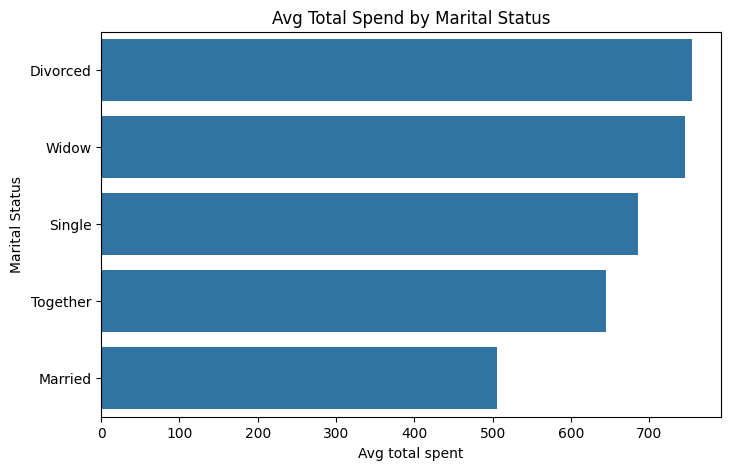

###  Response Rate by Income Band

In [ ]:
# Compute response rate by Income_Band
response_rate = df.groupby("Income_Band")["Response"].mean().mul(100).round(2).sort_values(ascending=False)

# Horizontal bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=response_rate.values, y=response_rate.index)
plt.title("Response Rate (%) by Income Band")
plt.xlabel("Response Rate (%)")
plt.ylabel("Income Band")

plt.show()

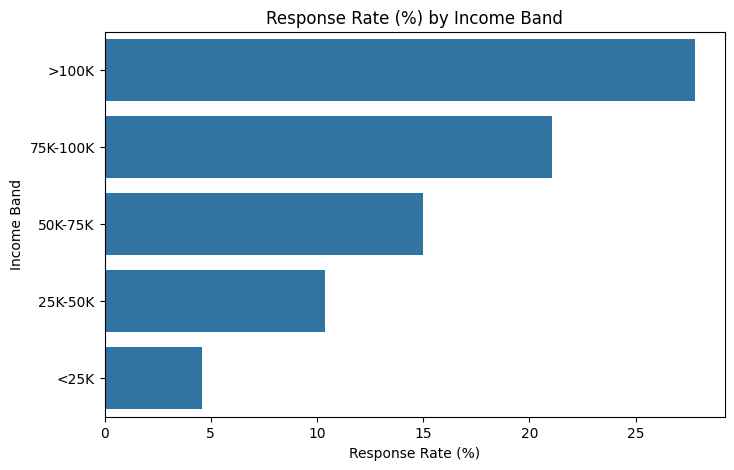

### Average Channel Usage

In [ ]:
print("\n--- Average Channel Usage ---")
# List of channels
channels = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases"]

# Compute average purchases per channel
avg_purchases = df[channels].mean()

# Horizontal bar plot
plt.figure(figsize=(8,5))
sns.barplot(x=avg_purchases.values, y=avg_purchases.index)
plt.title("Average Purchases per Channel")
plt.xlabel("Average Number of Purchases")
plt.ylabel("Channel")


plt.show()

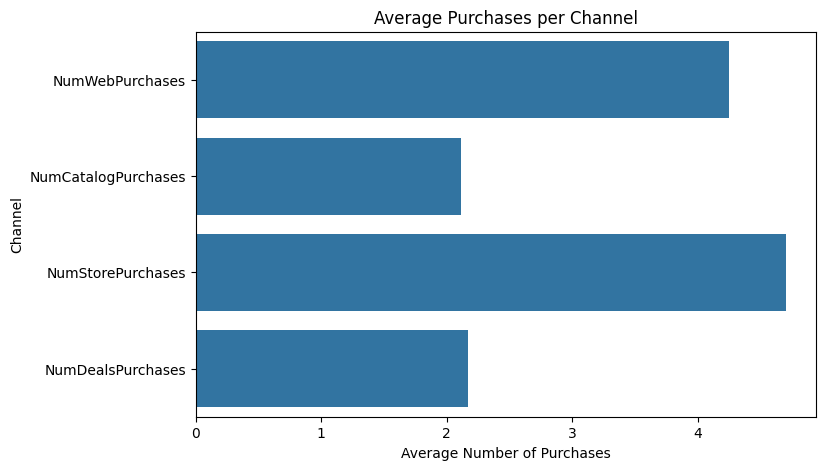

In [ ]:
# Channels
channels = ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases"]

# Overall averages
overall_avg = df[channels].mean()

# High-Value customers (>= 75th percentile)
spend_75th = df['Total_Spend'].quantile(0.75)
hv = df[df["Total_Spend"] >= spend_75th]
hv_avg = hv[channels].mean()

# Combine into a single DataFrame for plotting
plot_df = pd.DataFrame({
    'Overall': overall_avg,
    'High_Value': hv_avg
})

# Plot
plot_df.plot(kind='bar', figsize=(10,6), color=['skyblue', 'orange'])
plt.title("Channel Usage: High-Value vs Overall Customers")
plt.ylabel("Average Number of Purchases")
plt.xticks(rotation=0)

# Add exact values on top of bars
for i, ch in enumerate(channels):
    plt.text(i - 0.15, plot_df['Overall'][i] + 0.05, f"{plot_df['Overall'][i]:.2f}")
    plt.text(i + 0.05, plot_df['High_Value'][i] + 0.05, f"{plot_df['High_Value'][i]:.2f}")

plt.legend(title="")
plt.show()

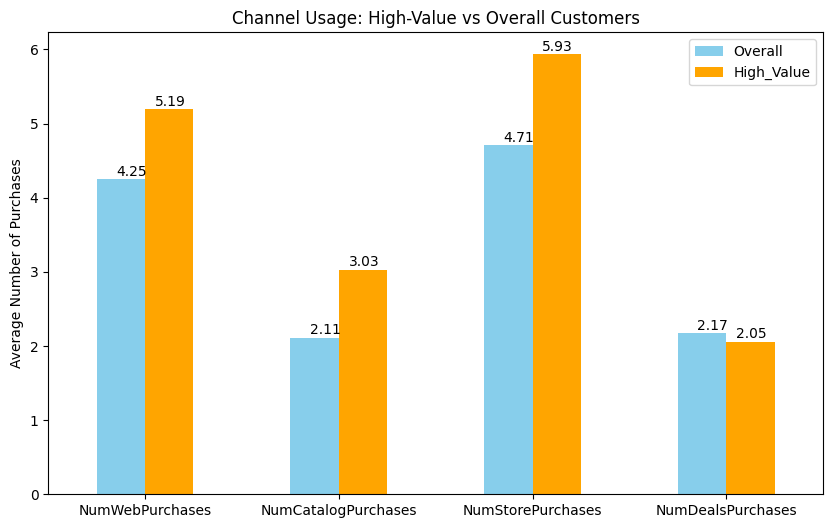

### Under-served Segment

In [117]:
underserved = df[
    (df["NumWebVisitsMonth"] >= 5) &
    (df["Total_Spend"] < spend_50th) &
    (df["Response"] == 0)
]
print(f"\n--- Under-served Segment: {len(underserved):,} customers ---")
print(f"  Avg Age: {underserved['Age'].mean():.1f}, Avg Income: {underserved['Income'].mean():.0f}")


--- Under-served Segment: 19,391 customers ---
  Avg Age: 40.8, Avg Income: 33338


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(underserved['Age'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

sns.histplot(underserved['Income'], bins=10, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Income Distribution")
axes[1].set_xlabel("Income")

plt.suptitle(f"Under-served Segment (n={len(underserved):,})")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

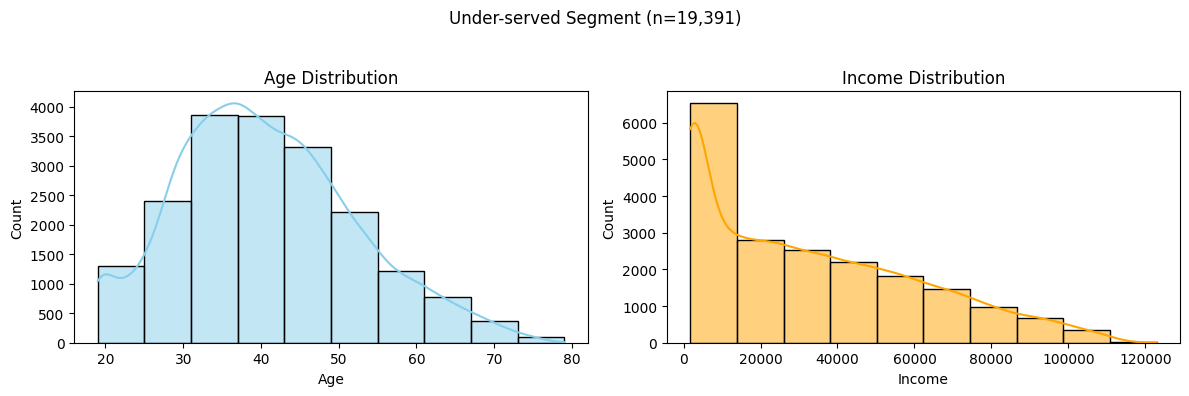

# export

In [ ]:
df.to_csv('marketing_clean.csv', index=False)
print(f"Clean CSV saved")

Clean CSV saved
